In [3]:
!pip install pandas
!pip install np

  Preparing metadata (setup.py) ... done
  Created wheel for np: filename=np-1.0.2-py3-none-any.whl size=13657 sha256=75cff47fb4be723c543e6de690443af71d4e21c59f2f028c70d178159dc90cc9
  Stored in directory: /root/.cache/pip/wheels/19/20/42/6ee214e617f78123903f603524d662ac6fa14154c3027fd992
Successfully built np


In [5]:
import requests
import pandas as pd

# ChEMBL base URL
base_url = "https://www.ebi.ac.uk"

# PPAR targets
targets = ['CHEMBL234', 'CHEMBL235', 'CHEMBL236']
all_data = []

for target in targets:
    print(f"Fetching data for {target}...")
    url = f"{base_url}/chembl/api/data/activity.json?target_chembl_id={target}&limit=1000"
    while url:
        res = requests.get(url)
        data = res.json()
        activities = data.get('activities', [])
        for act in activities:
            all_data.append({
                'molecule_chembl_id': act.get('molecule_chembl_id'),
                'target_chembl_id': act.get('target_chembl_id'),
                'standard_type': act.get('standard_type'),
                'standard_value': act.get('standard_value'),
                'standard_units': act.get('standard_units'),
                'canonical_smiles': act.get('canonical_smiles'),
                'pchembl_value': act.get('pchembl_value'),
                'activity_comment': act.get('activity_comment')
            })
        next_url = data.get('page_meta', {}).get('next')
        url = base_url + next_url if next_url else None

df = pd.DataFrame(all_data)

# Filter meaningful data
df = df[df['standard_type'].isin(['IC50', 'EC50', 'Ki', 'Kd', 'Potency'])]
df.dropna(subset=['standard_value', 'canonical_smiles'], inplace=True)

# compute pIC50
df['standard_value'] = df['standard_value'].astype(float)
df['pIC50'] = -df['standard_value'].apply(lambda x: np.log10(x * 1e-9) if x > 0 else None)

# Save to CSV
df.to_csv('ppar_binding_affinity_dataset.csv', index=False)
print("Dataset saved as 'ppar_binding_affinity_dataset.csv'")


Fetching data for CHEMBL234...
Fetching data for CHEMBL235...
Fetching data for CHEMBL236...
✅ Dataset saved as 'ppar_binding_affinity_dataset.csv'


In [6]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 52.3 MB/s eta 0:00:00


In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

# Load the CSV dataset
df = pd.read_csv("ppar_binding_affinity_dataset.csv")

# Create a list of descriptor names and functions
descriptor_list = [desc[0] for desc in Descriptors._descList]
descriptor_funcs = [desc[1] for desc in Descriptors._descList]

# Calculate descriptors
descriptor_data = []
valid_indices = []

for i, smi in enumerate(df['canonical_smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        values = [f(mol) for f in descriptor_funcs]
        descriptor_data.append(values)
        valid_indices.append(i)

# Keep only valid rows
descriptor_df = pd.DataFrame(descriptor_data, columns=descriptor_list)
df = df.iloc[valid_indices].reset_index(drop=True)
descriptor_df = descriptor_df.reset_index(drop=True)
df['pIC50'] = df['pIC50'].astype(float)

# Save processed features and labels
descriptor_df.to_csv("ppar_descriptors.csv", index=False)
df[['pIC50']].to_csv("ppar_labels.csv", index=False)

print("Descriptors saved as 'ppar_descriptors.csv'")
print("Labels saved as 'ppar_labels.csv'")

✅ Descriptors saved as 'ppar_descriptors.csv'
✅ Labels saved as 'ppar_labels.csv'


In [9]:
import numpy as np

# Check features
print("NaNs in X:", X.isna().sum().sum())
print("Infs in X:", np.isinf(X).sum().sum())

# Check labels
print("NaNs in y:", np.isnan(y).sum())
print("Infs in y:", np.isinf(y).sum())

NaNs in X: 868
Infs in X: 0
NaNs in y: 2
Infs in y: 0


In [10]:
# Combine and clean
data = X.copy()
data['pIC50'] = y
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

# Separate again
X_clean = data.drop(columns=['pIC50'])
y_clean = data['pIC50'].values

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=100, callbacks=[early_stop], verbose=1)

# Evaluate
predictions = model.predict(X_test_scaled).flatten()
loss, mae = model.evaluate(X_test_scaled, y_test)
r2 = 1 - np.sum((predictions - y_test)**2) / np.sum((y_test - np.mean(y_test))**2)

print(f"Test MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Epoch 1/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 5.1524 - mae: 1.5734 - val_loss: 1.2092 - val_mae: 0.8609
Epoch 2/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1430 - mae: 0.8220 - val_loss: 1.0483 - val_mae: 0.7950
Epoch 3/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0255 - mae: 0.7789 - val_loss: 0.9884 - val_mae: 0.7633
Epoch 4/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9390 - mae: 0.7346 - val_loss: 0.9959 - val_mae: 0.7578
Epoch 5/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8402 - mae: 0.6962 - val_loss: 1.0903 - val_mae: 0.8104
Epoch 6/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7974 - mae: 0.6763 - val_loss: 0.9176 - val_mae: 0.7218
Epoch 7/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.8211 - mae: 0.6814 - val_loss: 0.9131 - val_mae: 0.7211
Epoch 8/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7387 - mae: 0.6418 - val_loss: 0.9271 - val_mae: 0.7313
Epoch 9/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/

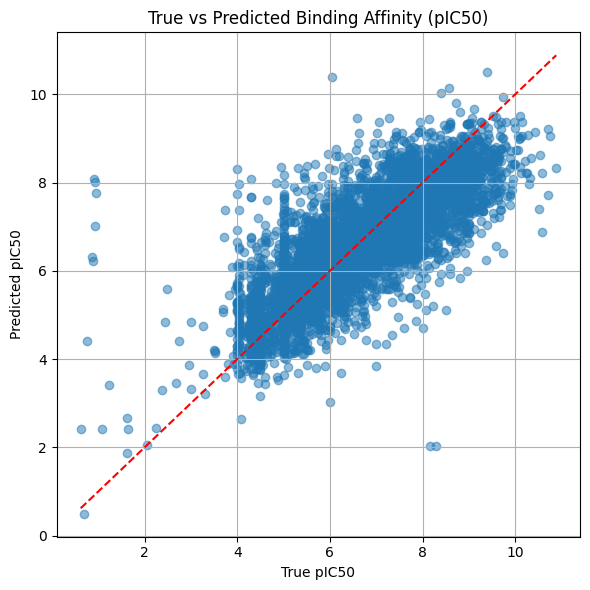

In [13]:
# Plot predictions
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel("True pIC50")
plt.ylabel("Predicted pIC50")
plt.title("True vs Predicted Binding Affinity (pIC50)")
plt.grid(True)
plt.tight_layout()
plt.show()